This project uses an Amazon Delivery Dataset with a comprehensive view of the company's last-mile logistics operations. It includes data on over 43,632 deliveries across multiple cities, with detailed information on order details, delivery agents, weather and traffic conditions, and delivery performance metrics. The dataset enables researchers and analysts to uncover insights into factors influencing delivery efficiency, identify areas for optimization, and explore the impact of various variables on the overall customer experience.

In [56]:
pip install kaggle geopy

Note: you may need to restart the kernel to use updated packages.


In [57]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from geopy.distance import geodesic # for calculating distances between coordinates

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

from sklearn.model_selection import RandomizedSearchCV # for hyperparameter tuning
from xgboost import XGBRegressor
from sklearn.ensemble import VotingRegressor # combine models for better performance
import joblib

### EDA

In [58]:
# import data
filepath = '/kaggle/input/datasets/sujalsuthar/amazon-delivery-dataset/amazon_delivery.csv'

df = pd.read_csv(filepath)
df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys


In [59]:
df.columns

Index(['Order_ID', 'Agent_Age', 'Agent_Rating', 'Store_Latitude',
       'Store_Longitude', 'Drop_Latitude', 'Drop_Longitude', 'Order_Date',
       'Order_Time', 'Pickup_Time', 'Weather', 'Traffic', 'Vehicle', 'Area',
       'Delivery_Time', 'Category'],
      dtype='object')

In [60]:
# check for duplicates
df.duplicated().sum()

np.int64(0)

In [61]:
# check for missing values
df.isnull().sum()

Order_ID            0
Agent_Age           0
Agent_Rating       54
Store_Latitude      0
Store_Longitude     0
Drop_Latitude       0
Drop_Longitude      0
Order_Date          0
Order_Time          0
Pickup_Time         0
Weather            91
Traffic             0
Vehicle             0
Area                0
Delivery_Time       0
Category            0
dtype: int64

In [62]:
# Check null values
print("Missing values:", df["Agent_Rating"].isnull().sum())

# See a sample of rows where rating is 0 or NaN to verify context
unrated_sample = df[(df["Agent_Rating"].isnull()) | (df["Agent_Rating"] == 0)]
print(unrated_sample.head())

Missing values: 54
           Order_ID  Agent_Age  Agent_Rating  Store_Latitude  Store_Longitude  \
124   uurs547552548         23           NaN       22.569358        88.433452   
1996  xoaj834389107         32           NaN        0.000000         0.000000   
2002  lasr795083832         23           NaN       25.454648        81.834502   
2018  gjcr517387117         26           NaN        0.000000         0.000000   
3253  ohgx024912559         32           NaN       19.874733        75.353942   

      Drop_Latitude  Drop_Longitude  Order_Date Order_Time Pickup_Time  \
124       22.599358       88.463452  2022-02-17   23:25:00    23:35:00   
1996       0.050000        0.050000  2022-02-11   20:50:00    21:00:00   
2002      25.584648       81.964502  2022-02-18   19:50:00    19:55:00   
2018       0.080000        0.080000  2022-02-16   23:50:00    23:55:00   
3253      19.984733       75.463942  2022-02-16   18:35:00    18:50:00   

         Weather  Traffic      Vehicle           

The data has no duplicates but it has missing values in the Agent_Rating(54) and Weather(91) columns. Since these rows account for less than 1% of the data, drop them. 
**However, some store and pickup coordinates are 0.000, which is a common error that occurs when geocoding fails. It should be fixed for any distance related features.**

In [63]:
df = df.dropna()
df.isnull().sum()

Order_ID           0
Agent_Age          0
Agent_Rating       0
Store_Latitude     0
Store_Longitude    0
Drop_Latitude      0
Drop_Longitude     0
Order_Date         0
Order_Time         0
Pickup_Time        0
Weather            0
Traffic            0
Vehicle            0
Area               0
Delivery_Time      0
Category           0
dtype: int64

#### Visualizations

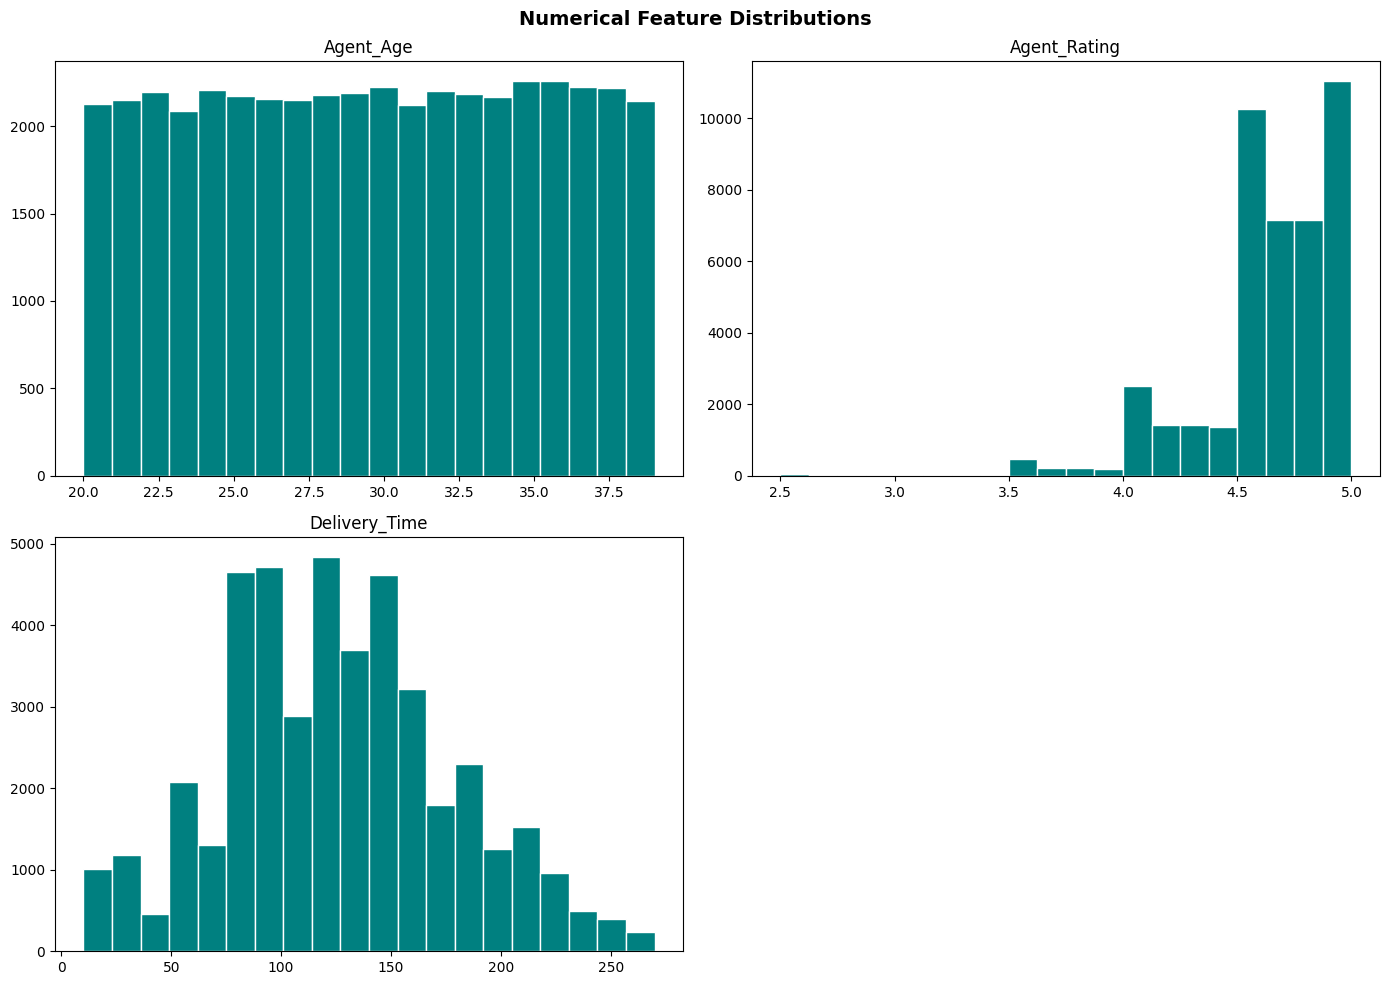

In [64]:
num_cols = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
# Filter out coordinate columns
num_cols = [
    col
    for col in num_cols
    if not any(coord in col.lower() for coord in ["lat", "lon"])
]

# 2. Plot histograms
df[num_cols].hist(
    bins=20,
    color="teal",
    edgecolor="white",
    grid=False,
    figsize=(14, 10),
    xlabelsize=10,
    ylabelsize=10,
)

plt.suptitle(
    "Numerical Feature Distributions",
    fontsize=14,
    fontweight="bold",
)
plt.tight_layout()
plt.show()

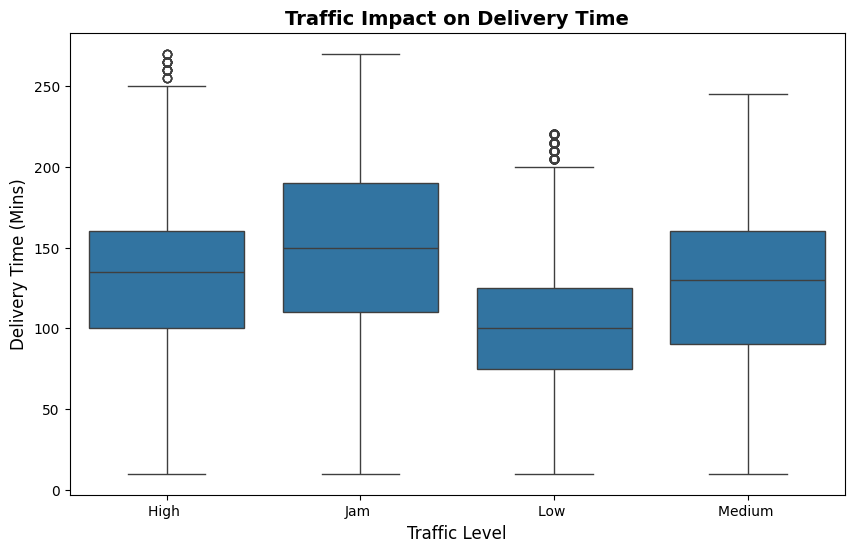

In [65]:
# Traffic Conditions vs Delivery Time
plt.figure(figsize=(10, 6))
sns.boxplot(x="Traffic", y="Delivery_Time", data=df)
plt.title(
    "Traffic Impact on Delivery Time",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Traffic Level", fontsize=12)
plt.ylabel("Delivery Time (Mins)", fontsize=12)
plt.show()

* The boxplots show outliers in delivery time(extreme highs).
* Delivery times clearly escalate as traffic congestion worsens, moving predictably from Low up to Jam.
* Under Low traffic, the median delivery time hovers around 100 minutes, with most deliveries tightly bounded.
* During a Jam, the median delivery time jumps to roughly 150 minutes, and the upper quartile stretches past 200 minutes.
* This can create traffic tiers and surge multipliers into a courier payout calculator as congestion drastically inflates operational timelines.

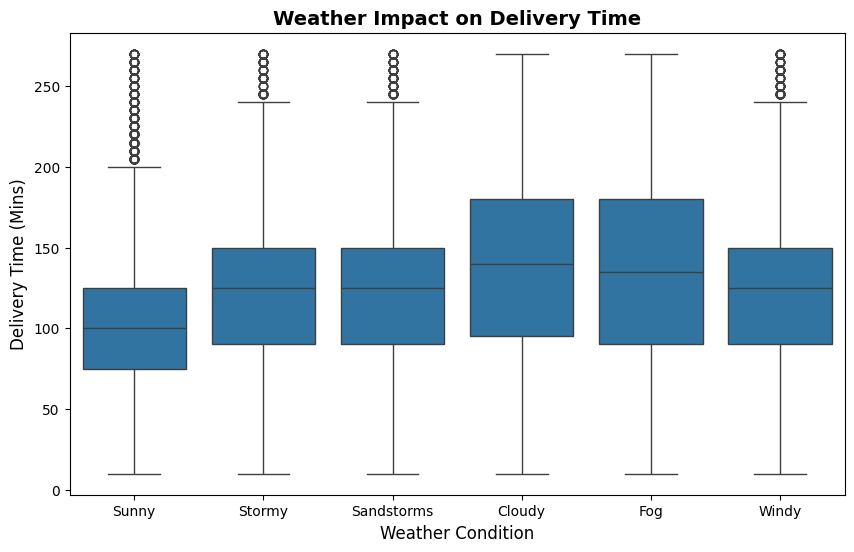

In [66]:
# Weather Conditions vs Delivery Time
plt.figure(figsize=(10, 6))
sns.boxplot(x="Weather", y="Delivery_Time", data=df)
plt.title(
    "Weather Impact on Delivery Time",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Weather Condition", fontsize=12)
plt.ylabel("Delivery Time (Mins)", fontsize=12)
plt.show()

* Adverse weather conditions noticeably spike delivery times compared to clear skies.
* Sunny conditions have better delivery times(a median of around 100 minutes).
* Cloudy and Fog conditions have higher medians (closer to 135–140 minutes) and broader spreads, showing that visibility and environmental conditions severely constrain delivery time. 

#### Feature Engineering to Get Distance

In [67]:
# Distance vs delivery time 

#feature engineer distance from pickup and delivery coordinates
# confirm for 0.0 values in coordinates(geocoding errors)
print("Count of Store_Longitude:", (df["Store_Longitude"] == 0).sum())

# sample rows where rating is 0.0 or NaN 
latitude_sample = df[(df["Store_Latitude"].isnull()) | (df["Store_Latitude"] == 0)]
print(latitude_sample.head())

# handle 0.0 coordinate values
lat_lon_cols = [
      "Store_Latitude",
      "Store_Longitude",
      "Drop_Latitude",
      "Drop_Longitude",
  ]

# loop through all location columns to replace 0.0 with NaN
for col in lat_lon_cols:
    df[col] = df[col].replace(0.0, np.nan)  # replace 0.0 with null values

df = df.dropna(subset=lat_lon_cols)     # drop rows with missing GPS coordinates(nulls cause errors in distance calculation)

# Engineer a distance feature
def calculate_accurate_distance(df):
  # calculate true geodesic distance in kilometers
  def get_geodesic_distance(row):
    store_coords = (row["Store_Latitude"], row["Store_Longitude"])
    drop_coords = (row["Drop_Latitude"], row["Drop_Longitude"])
    try:
      return geodesic(store_coords, drop_coords).kilometers
    except Exception:
      return None  # Catches any rogue invalid coordinates

  # Apply across the dataframe
  df["Distance(km)"] = df.apply(get_geodesic_distance, axis=1)

  return df

# Call the function to compute the column
df = calculate_accurate_distance(df)
df.head()


Count of Store_Longitude: 3485
         Order_ID  Agent_Age  Agent_Rating  Store_Latitude  Store_Longitude  \
33  zotl583816092         32           3.5             0.0              0.0   
51  dcdm719150402         25           5.0             0.0              0.0   
56  bbow373480117         39           4.2             0.0              0.0   
58  etss702593505         36           4.7             0.0              0.0   
66  emlt327861941         23           4.8             0.0              0.0   

    Drop_Latitude  Drop_Longitude  Order_Date Order_Time Pickup_Time Weather  \
33           0.11            0.11  2022-03-08   21:35:00    21:45:00  Stormy   
51           0.03            0.03  2022-02-13   22:10:00    22:25:00  Cloudy   
56           0.08            0.08  2022-03-02   20:35:00    20:50:00     Fog   
58           0.06            0.06  2022-03-13   20:15:00    20:20:00  Cloudy   
66           0.02            0.02  2022-03-07   10:40:00    10:50:00  Stormy   

   Traffic   

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,Weather,Traffic,Vehicle,Area,Delivery_Time,Category,Distance(km)
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,Sunny,High,motorcycle,Urban,120,Clothing,3.020737
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,Stormy,Jam,scooter,Metropolitian,165,Electronics,20.143737
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,Sandstorms,Low,motorcycle,Urban,130,Sports,1.549693
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,Sunny,Medium,motorcycle,Metropolitian,105,Cosmetics,7.774497
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,Cloudy,High,scooter,Metropolitian,150,Toys,6.197898


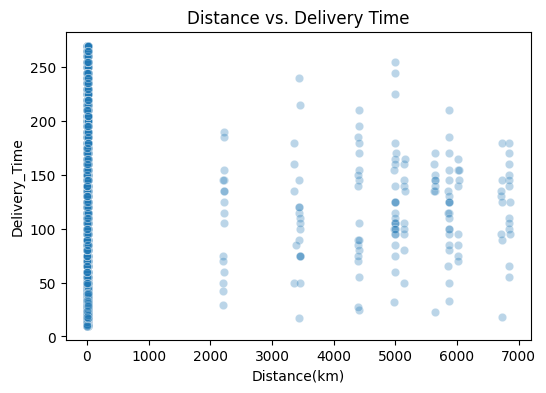

In [68]:
# visualize distance vs delivery time
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="Distance(km)", y="Delivery_Time", alpha=0.3)
plt.title("Distance vs. Delivery Time")
plt.show()

The 0KM mark confirms the anomaly with geolocation, suggesting some orders were logged with a distance of zero, despite having a 250-minute delivery time.

The scatterplot also shows a dispersed spread of deliveries, with an interesting vertical layout across varying distances, perhaps because traffic congestion and preparation time weigh far more heavily on total delivery duration than raw travel distance alone.

<Axes: xlabel='Order_Time', ylabel='Delivery_Time'>

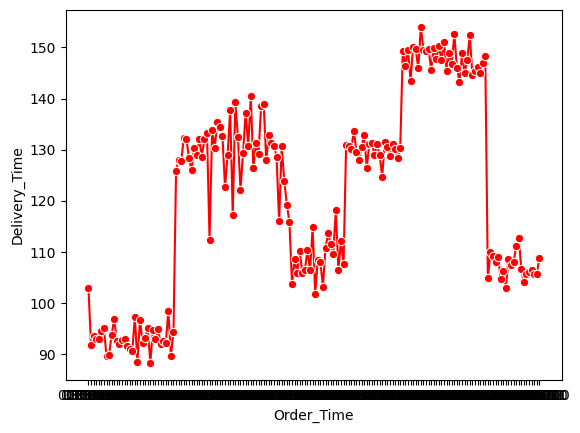

In [69]:
# Hourly Rush Hour Curve
hourly_trend = (
  df.groupby("Order_Time")["Delivery_Time"].mean().reset_index()
)
sns.lineplot(
  x="Order_Time",
  y="Delivery_Time",
  data=hourly_trend,
  marker="o",
  color="r",
)
# axes[1, 0].set_title("Macro View: Average Delivery Time by Hour of Day")

The lineplot highlights sharp daily operational shifts, including at 90-100 minutes, rising abruptly to around 120-150 minutes, etc. These shifts represent traffic jams,severe weather shifts,or regional demands where delivery issues spike delivery times.

<Axes: >

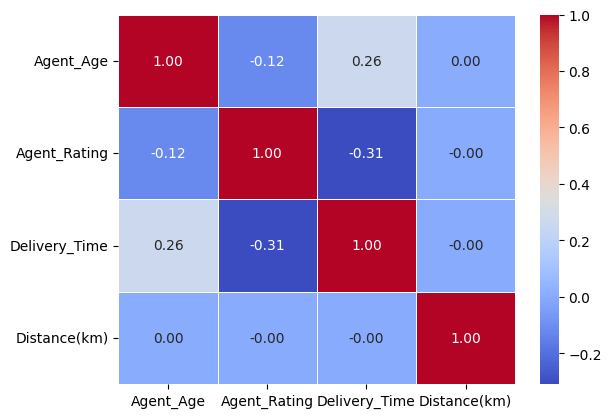

In [70]:
# Correlation Matrix of Numerical Features
numeric_cols = [
            'Agent_Age',
            'Agent_Rating',
            'Delivery_Time',
            'Distance(km)'
           ]
corr = df[numeric_cols].corr()
sns.heatmap(
  data=corr,
  annot=True,
  cmap="coolwarm",
  fmt=".2f",
  linewidths=0.5,
)

The **correlation matrix confirms there are significant outliers** in the data since there's no correlation between distance, agent age, agent rating, and the most important feature, delivery_time(dependent variable). 

To fix, check the summary statistics and handle the outliers accordingly. Distance has a maximum of 6800km and a maximum delivery time of 270 minutes. This is an impractical feat, unless the agent travelled at supersonic speed, so it signals data quality issues.

In [71]:
# Summary stats distance column
df.describe()


,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Delivery_Time,Distance(km)
count,40109.000000,40109.000000,40109.000000,40109.000000,40109.000000,40109.000000,40109.000000,40109.000000
mean,29.554339,4.633987,18.743136,76.917882,18.973257,76.981513,125.086140,28.109712
std,5.760159,0.314886,6.015791,3.498063,5.471796,3.498268,51.932193,310.791976
min,20.000000,2.500000,-30.902872,72.768726,9.967144,72.778726,10.000000,1.463837
25%,25.000000,4.500000,12.981615,73.898520,13.065801,73.940547,90.000000,4.648491
50%,30.000000,4.700000,19.055831,76.618203,19.123249,76.662620,125.000000,9.177784
75%,35.000000,4.900000,22.750040,78.347554,22.820040,78.402621,160.000000,13.660190
max,39.000000,5.000000,30.914057,88.433452,31.054057,88.563452,270.000000,6852.617172


**EDA Insights**
Traffic Impact: Traffic congestion is one of the heaviest drivers of delay. Transitioning from "Low" traffic to a heavy "Jam" shifts median delivery times from roughly 100 minutes up to 150+ minutes, with upper quartiles stretching past 200 minutes.

Weather Friction: Adverse weather conditions (such as fog, clouds, or storms) widen the distribution spread and elevate baseline delivery times compared to clear, sunny days.

Application: These features directly enabled your champion tree ensemble (VotingRegressor) to model non-linear trade-offs, power real-time ETA predictions, and calculate dynamic courier payouts under varying traffic surges.

### Preprocessing

In [72]:
# Handle outliers
# Calculate IQR for Distance(km)
Q1 = df["Distance(km)"].quantile(0.25)
Q3 = df["Distance(km)"].quantile(0.75)
IQR = Q3 - Q1

# Keep data within 1.5 * IQR bounds
df = df[
    (df["Distance(km)"] >= (Q1 - 1.5 * IQR))
    & (df["Distance(km)"] <= (Q3 + 1.5 * IQR))
]

<Axes: >

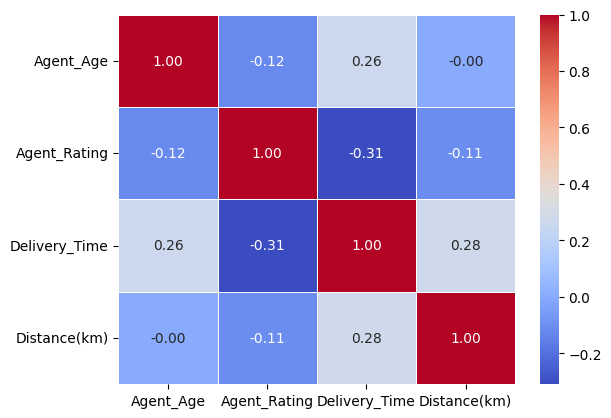

In [73]:
# Check fixed correlation(if removing outliers worked)
numeric_cols = [
            'Agent_Age',
            'Agent_Rating',
            'Delivery_Time',
            'Distance(km)'
           ]
corr = df[numeric_cols].corr()
sns.heatmap(
  data=corr,
  annot=True,
  cmap="coolwarm",
  fmt=".2f",
  linewidths=0.5,
)

From the fixed correlation heatmap:

There's **a positive correlation** in the following order;
* delivery time and distance at 0.28 (longer distances have longer delivery times)
* delivery time and agent age at 0.26 (older agents have longer delivery times)

There's a **strong negative correlation** in the following order;
* delivery time and agent rating at -0.31(delivery times are longer when agent ratings are low)

and **weaker neglible negative correlations** in;
* agent rating and agent age at -0.12
* distance at agent rating at -0.11

There's **no correlation between agent_age and distance**(age does not affect distance, vice versa) 

#### Encode Categorical Columns

In [74]:
df = pd.get_dummies(
    df, 
    columns=["Weather", "Traffic", "Vehicle", "Area"], 
    drop_first=True,
    dtype=int,
)

df.head()

,Order_ID,Agent_Age,Agent_Rating,Store_Latitude,Store_Longitude,Drop_Latitude,Drop_Longitude,Order_Date,Order_Time,Pickup_Time,...,Weather_Sunny,Weather_Windy,Traffic_Jam,Traffic_Low,Traffic_Medium,Vehicle_scooter,Vehicle_van,Area_Other,Area_Semi-Urban,Area_Urban
0,ialx566343618,37,4.9,22.745049,75.892471,22.765049,75.912471,2022-03-19,11:30:00,11:45:00,...,1,0,0,0,0,0,0,0,0,1
1,akqg208421122,34,4.5,12.913041,77.683237,13.043041,77.813237,2022-03-25,19:45:00,19:50:00,...,0,0,1,0,0,1,0,0,0,0
2,njpu434582536,23,4.4,12.914264,77.678400,12.924264,77.688400,2022-03-19,08:30:00,08:45:00,...,0,0,0,1,0,0,0,0,0,1
3,rjto796129700,38,4.7,11.003669,76.976494,11.053669,77.026494,2022-04-05,18:00:00,18:10:00,...,1,0,0,0,1,0,0,0,0,0
4,zguw716275638,32,4.6,12.972793,80.249982,13.012793,80.289982,2022-03-26,13:30:00,13:45:00,...,0,0,0,0,0,1,0,0,0,0


### Train Models

In [75]:
# Select features and target variable
drop_cols = [
    "Order_ID",
    "Order_Date",
    "Order_Time",
    "Pickup_Time",
    "Delivery_Time",
    "Category",
]
X = df.drop(columns=[col for col in drop_cols if col in df.columns])
y = df["Delivery_Time"]

# Train/Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Initialize the scaler for linear regression model
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Linear Regression(Base Model)

In [76]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_preds = lr.predict(X_test_scaled)

lr_mae = mean_absolute_error(y_test, lr_preds)
print(f"Linear Regression MAE: {lr_mae:.2f} mins")

Linear Regression MAE: 30.78 mins


#### Random Forest(Ensemble Model)

In [77]:
# Random forests don't strictly require scaled data, so pass raw X_train/X_test
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

rf_mae = mean_absolute_error(y_test, rf_preds)
print(f"Random Forest MAE: {rf_mae:.2f} mins")

Random Forest MAE: 25.51 mins


In [78]:
# Initialize XGBoost Regressor
xgb = XGBRegressor(n_estimators=150, learning_rate=0.1, random_state=42)
xgb.fit(X_train, y_train)
xgb_preds = xgb.predict(X_test)

print(
    f"XGBoost MAE: {mean_absolute_error(y_test, xgb_preds):.2f} mins"
)  # Usually beats Random Forest!

XGBoost MAE: 24.37 mins


#### Hyperparameter Tuning the XGB model

In [79]:
# Define the grid of hyperparameters to test
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7, 10],
    "learning_rate": [0.01, 0.05, 0.1, 0.2],
    "subsample": [0.7, 0.8, 1.0],
    "colsample_bytree": [0.7, 0.8, 1.0],
}

# Initialize base model
xgb_base = XGBRegressor(random_state=42)

# Set up Randomized Search (testing 10 random combinations with 3-fold cross-validation)
random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=10,
    scoring="neg_mean_absolute_error",
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1,
)

# Fit on training data
random_search.fit(X_train, y_train)

# Extract the best model and evaluate
best_xgb = random_search.best_estimator_
best_preds = best_xgb.predict(X_test)

print("Best Parameters Found:", random_search.best_params_)
print(f"Optimized XGBoost MAE: {mean_absolute_error(y_test, best_preds):.2f} mins")

Fitting 3 folds for each of 10 candidates, totalling 30 fits
Best Parameters Found: {'subsample': 0.7, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.05, 'colsample_bytree': 0.8}
Optimized XGBoost MAE: 24.55 mins


The XGB model had the best delivery time at 24.37 minutes compared to the linear regression model at 30.78 minutes and 25.55 minutes for the Random Forest Model. **Hyperparameter tuning the XGB model yielded almost the same delivery time at 24.55 minutes, showing the model is stable.**

### Ensemble the Best Tree Models With a Voting Regressor

In [80]:
# Ensemble best tree models
tree_ensemble = VotingRegressor(
    estimators=[
        ("rf", RandomForestRegressor(n_estimators=50, random_state=42)),
        (
            "xgb",
            XGBRegressor(
                n_estimators=100, learning_rate=0.05, random_state=42
            ),
        ),
    ]
)

tree_ensemble.fit(X_train, y_train)
tree_preds = tree_ensemble.predict(X_test)
print(
    f"Tree Ensemble MAE: {mean_absolute_error(y_test, tree_preds):.2f} mins"
)

Tree Ensemble MAE: 24.38 mins


**The tree ensemble model has the best delivery time performance at 24.38 minutes, so it's the best the model.******

### Save Best Model

In [81]:
# Save tree ensemble
joblib.dump(tree_ensemble, "tree_ensemble_model.pkl", compress=9)
joblib.dump(list(X.columns), "model_features.pkl")

print("Tree ensemble model and features saved")

Tree ensemble model and features saved


In [82]:
# # deleting kaggle outputs
# # Specify the path to the output file
# file_path = '/kaggle/working/model_features.pkl'
# # Check if the file exists
# if os.path.exists(file_path):
#    # Remove the file
#    os.remove(file_path)
#    print(f"{file_path} has been deleted.")
# else:
#    print(f"{file_path} does not exist.")